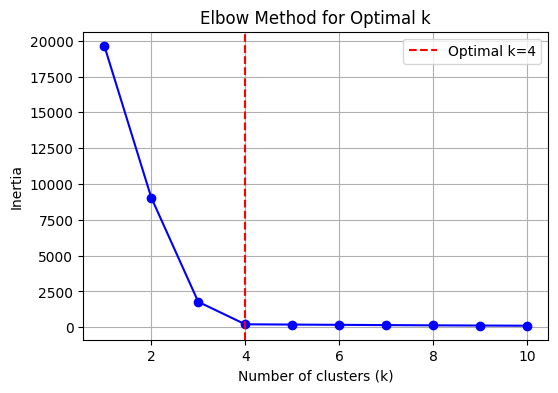

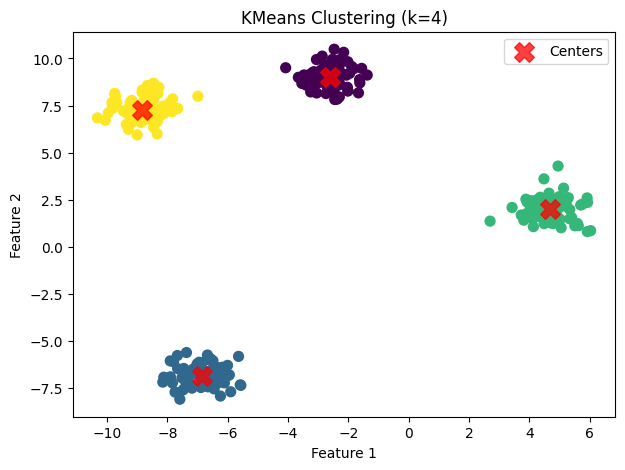

Silhouette Score (k=4): 0.876


In [3]:
# Simple KMeans Clustering Example
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Elbow method to find optimal k
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, 'bo-')
plt.axvline(x=4, color='red', linestyle='--', label='Optimal k=4')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.legend()
plt.grid(True)
plt.show()

# Fit KMeans with optimal k (choose visually, e.g., k=4)
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42)
labels = kmeans.fit_predict(X)

# Plot clusters
plt.figure(figsize=(7,5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centers')
plt.title(f'KMeans Clustering (k={k_opt})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# Silhouette score
score = silhouette_score(X, labels)
print(f'Silhouette Score (k={k_opt}): {score:.3f}')


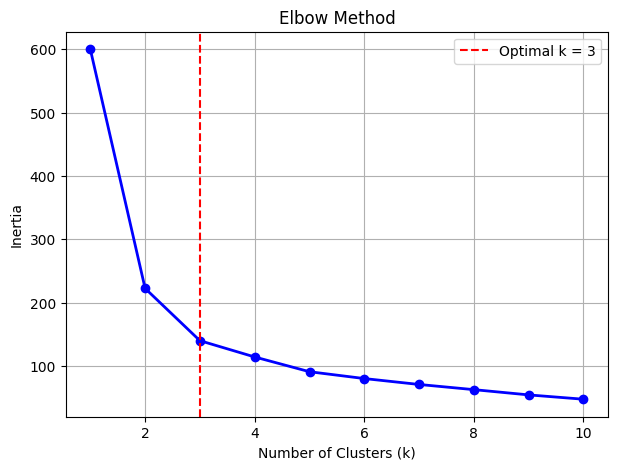

Silhouette Score: 0.46

Cluster Sizes
Cluster 0: 53 observations
Cluster 1: 50 observations
Cluster 2: 47 observations

Cluster Feature Means
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
0                 5.801887          2.673585           4.369811   
1                 5.006000          3.428000           1.462000   
2                 6.780851          3.095745           5.510638   

         petal width (cm)  
Cluster                    
0                1.413208  
1                0.246000  
2                1.972340  


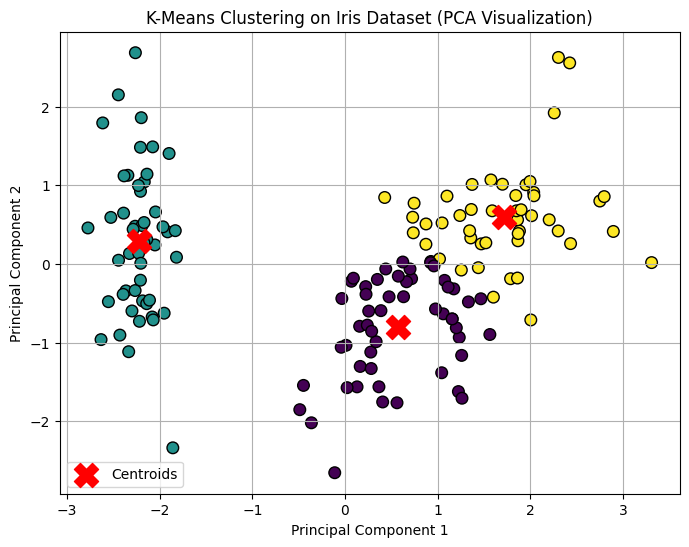

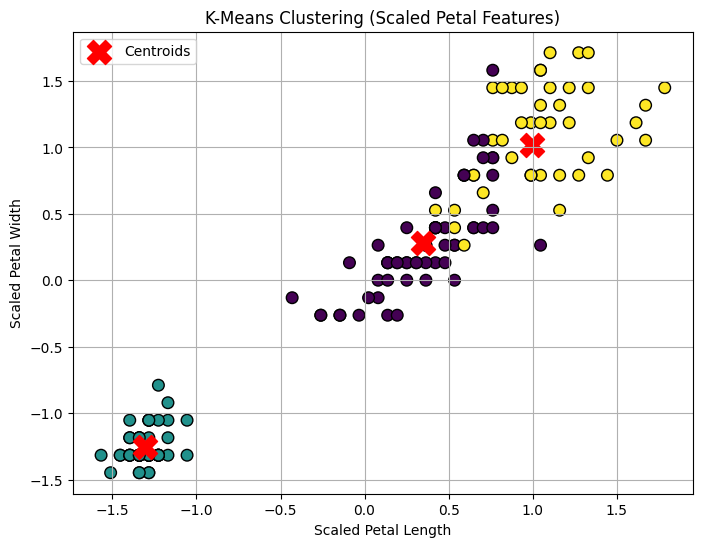


Scaled Feature Variance
sepal length (cm)   : 1.000
sepal width (cm)    : 1.000
petal length (cm)   : 1.000
petal width (cm)    : 1.000

Suggestions to Improve Clustering
- Feature Scaling using StandardScaler (Done)
- K-Means++ Initialization (Done)
- Increased n_init to 50 for better centroid selection
- Increased max_iter to 500
- PCA used for better visualization
- Petal features provide better separation than sepal features
- Try Gaussian Mixture Models (GMM) for overlapping clusters
- Evaluate different values of k using Silhouette Score
- Remove outliers for larger real-world datasets


In [1]:
# K-Means Clustering on Iris Dataset with Feature Scaling and Improved Segmentation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------
iris = load_iris()
X = iris.data

# --------------------------------------------------
# Feature Scaling (Important for K-Means)
# --------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------
# Elbow Method
# --------------------------------------------------
inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=50,
        max_iter=500,
        random_state=42
    )
    km.fit(X_scaled)
    inertia.append(km.inertia_)

k_opt = 3

plt.figure(figsize=(7,5))
plt.plot(K, inertia, 'bo-', linewidth=2)
plt.axvline(k_opt, color='red', linestyle='--', label='Optimal k = 3')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Train Final K-Means Model
# --------------------------------------------------
kmeans = KMeans(
    n_clusters=k_opt,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)

# --------------------------------------------------
# Silhouette Score
# --------------------------------------------------
score = silhouette_score(X_scaled, labels)

print("="*50)
print("Silhouette Score:", round(score,3))
print("="*50)

# --------------------------------------------------
# Number of observations in each cluster
# --------------------------------------------------
unique, counts = np.unique(labels, return_counts=True)

print("\nCluster Sizes")
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} observations")

# --------------------------------------------------
# Cluster Means (Original Values)
# --------------------------------------------------
df = pd.DataFrame(X, columns=iris.feature_names)
df['Cluster'] = labels

print("\nCluster Feature Means")
print(df.groupby("Cluster").mean())

# --------------------------------------------------
# PCA for Better Visualization
# --------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='viridis',
    s=70,
    edgecolor='k'
)

plt.scatter(
    centers_pca[:,0],
    centers_pca[:,1],
    c='red',
    marker='X',
    s=300,
    label='Centroids'
)

plt.title("K-Means Clustering on Iris Dataset (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# Visualization using Scaled Petal Features
# --------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,2],
    X_scaled[:,3],
    c=labels,
    cmap='viridis',
    s=70,
    edgecolor='k'
)

plt.scatter(
    kmeans.cluster_centers_[:,2],
    kmeans.cluster_centers_[:,3],
    c='red',
    marker='X',
    s=300,
    label='Centroids'
)

plt.xlabel("Scaled Petal Length")
plt.ylabel("Scaled Petal Width")
plt.title("K-Means Clustering (Scaled Petal Features)")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# Feature Importance (Variance)
# --------------------------------------------------
feature_variance = np.var(X_scaled, axis=0)

print("\nScaled Feature Variance")
for name, var in zip(iris.feature_names, feature_variance):
    print(f"{name:20s}: {var:.3f}")

# --------------------------------------------------
# Suggestions to Improve Clustering
# --------------------------------------------------
print("\nSuggestions to Improve Clustering")
print("- Feature Scaling using StandardScaler (Done)")
print("- K-Means++ Initialization (Done)")
print("- Increased n_init to 50 for better centroid selection")
print("- Increased max_iter to 500")
print("- PCA used for better visualization")
print("- Petal features provide better separation than sepal features")
print("- Try Gaussian Mixture Models (GMM) for overlapping clusters")
print("- Evaluate different values of k using Silhouette Score")
print("- Remove outliers for larger real-world datasets")

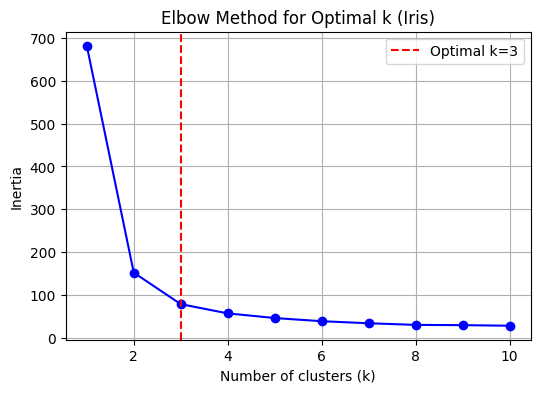

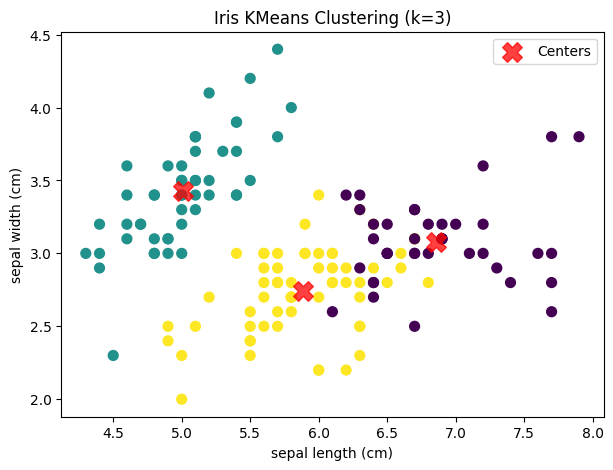

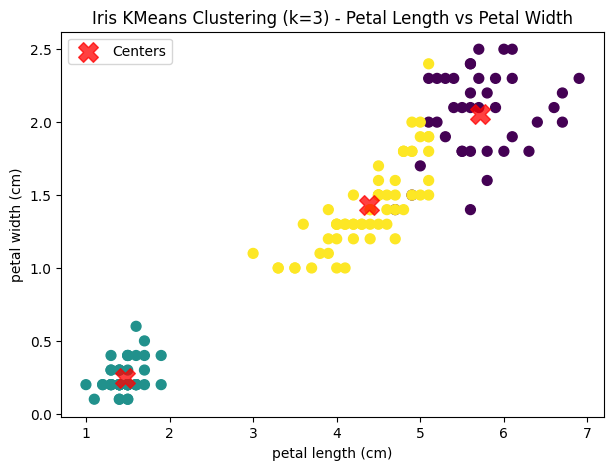

Silhouette Score (k=3): 0.551
Cluster 0: 39 data points
Cluster 1: 50 data points
Cluster 2: 61 data points

Cluster feature means:
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
cluster                                                           
0                 6.853846          3.076923           5.715385   
1                 5.006000          3.428000           1.462000   
2                 5.883607          2.740984           4.388525   

         petal width (cm)  
cluster                    
0                2.053846  
1                0.246000  
2                1.434426  


In [4]:
# KMeans Clustering on Iris Dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# Load Iris data
iris = load_iris()
X = iris.data

# Elbow method to find optimal k
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
k_opt = 3  # Set optimal k explicitly for Iris data
plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, 'bo-')
plt.axvline(x=k_opt, color='red', linestyle='--', label='Optimal k=3')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k (Iris)')
plt.legend()
plt.grid(True)
plt.show()

# Fit KMeans with optimal k (choose visually, e.g., k=3)
kmeans = KMeans(n_clusters=k_opt, random_state=42)
labels = kmeans.fit_predict(X)

# Plot clusters (using first two features for visualization)
plt.figure(figsize=(7,5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centers')
plt.title(f'Iris KMeans Clustering (k={k_opt})')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.show()

# Plot clusters (using petal length and petal width for visualization)
plt.figure(figsize=(7,5))
plt.scatter(X[:, 2], X[:, 3], c=labels, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], c='red', s=200, alpha=0.75, marker='X', label='Centers')
plt.title(f'Iris KMeans Clustering (k={k_opt}) - Petal Length vs Petal Width')
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.legend()
plt.show()

# Silhouette score
score = silhouette_score(X, labels)
print(f'Silhouette Score (k={k_opt}): {score:.3f}')

# Number of observations in each cluster
unique, counts = np.unique(labels, return_counts=True)
for i, count in zip(unique, counts):
    print(f"Cluster {i}: {count} data points")

# Descriptive summary of each cluster (mean feature values)
df = pd.DataFrame(X, columns=iris.feature_names)
df['cluster'] = labels
print("\nCluster feature means:")
print(df.groupby('cluster').mean())